# Orang 5 — Testing, Eksperimen & Grafik
Menjalankan program dari `03_genetic_algorithm_implementation.ipynb` tanpa mendefinisikan ulang fungsi GA.
Melakukan eksperimen 5 konfigurasi parameter, mencatat hasil, membuat grafik konvergensi, file Excel, dan ringkasan.

In [2]:
# %%capture
# # Menjalankan seluruh program dari 03 untuk mengimpor fungsi dan data (S, y) yang diperlukan.
# # %%capture agar output panjang dari 03 tidak mengotori notebook 04.
# %run -i 03_genetic_algorithm_implementation.ipynb

In [3]:
import time
import pandas as pd
import matplotlib.pyplot as plt

# Konfigurasi eksperimen (sesuai Tabel 3.4 laporan)
configs = [
    {"Konfigurasi": 1, "Populasi": 30,  "Generasi": 50,  "Crossover Rate": 0.7,  "Mutation Rate": 0.1},
    {"Konfigurasi": 2, "Populasi": 50,  "Generasi": 100, "Crossover Rate": 0.8,  "Mutation Rate": 0.1},
    {"Konfigurasi": 3, "Populasi": 100, "Generasi": 150, "Crossover Rate": 0.9,  "Mutation Rate": 0.2},
    {"Konfigurasi": 4, "Populasi": 150, "Generasi": 200, "Crossover Rate": 0.85, "Mutation Rate": 0.15},
    {"Konfigurasi": 5, "Populasi": 80,  "Generasi": 80,  "Crossover Rate": 0.75, "Mutation Rate": 0.25},
]

hasil_eksperimen = []
history_all = []
print("Memulai pengujian konfigurasi parameter...")

for conf in configs:
    print(f"\nMenjalankan Konfigurasi {conf['Konfigurasi']}...")
    # Atur parameter global pada namespace fungsi dari 03
    run_genetic_algorithm.__globals__['POP_SIZE'] = conf["Populasi"]
    run_genetic_algorithm.__globals__['MAX_GEN'] = conf["Generasi"]
    run_genetic_algorithm.__globals__['P_C'] = conf["Crossover Rate"]
    run_genetic_algorithm.__globals__['P_M'] = conf["Mutation Rate"]

    start = time.time()
    best_w, best_fit, history = run_genetic_algorithm()
    waktu = time.time() - start

    generasi_terbaik = history.index(best_fit) + 1
    rata_rata = sum(history) / len(history)

    hasil_eksperimen.append({
        "Konfigurasi": conf["Konfigurasi"],
        "Populasi": conf["Populasi"],
        "Generasi": conf["Generasi"],
        "Crossover Rate": conf["Crossover Rate"],
        "Mutation Rate": conf["Mutation Rate"],
        "Best Fitness": round(best_fit, 6),
        "Best Spearman": round(2*best_fit - 1, 6),
        "Rata-rata Fitness": round(rata_rata, 6),
        "Waktu Komputasi (s)": round(waktu, 2),
        "Generasi Terbaik": generasi_terbaik,
        "w_distance": round(best_w[0], 4),
        "w_traffic": round(best_w[1], 4),
        "w_weather": round(best_w[2], 4),
        "w_vehicle": round(best_w[3], 4),
        "w_agent": round(best_w[4], 4),
    })
    history_all.append({"Konfigurasi": conf["Konfigurasi"], "History": history})

df_hasil = pd.DataFrame(hasil_eksperimen)
print("\n--- TABEL HASIL EKSPERIMEN ---")
display(df_hasil)

Memulai pengujian konfigurasi parameter...

Menjalankan Konfigurasi 1...
Generasi 1/50 | Best Fitness: 0.735262
Generasi 10/50 | Best Fitness: 0.752435
Generasi 20/50 | Best Fitness: 0.753079
Generasi 30/50 | Best Fitness: 0.753094
Generasi 40/50 | Best Fitness: 0.753379
Generasi 50/50 | Best Fitness: 0.753385

Menjalankan Konfigurasi 2...
Generasi 1/100 | Best Fitness: 0.745661
Generasi 10/100 | Best Fitness: 0.750074
Generasi 20/100 | Best Fitness: 0.752752
Generasi 30/100 | Best Fitness: 0.753530
Generasi 40/100 | Best Fitness: 0.753535
Generasi 50/100 | Best Fitness: 0.753550
Generasi 60/100 | Best Fitness: 0.753596
Generasi 70/100 | Best Fitness: 0.753597
Generasi 80/100 | Best Fitness: 0.754227
Generasi 90/100 | Best Fitness: 0.754227
Generasi 100/100 | Best Fitness: 0.754227

Menjalankan Konfigurasi 3...
Generasi 1/150 | Best Fitness: 0.745928
Generasi 10/150 | Best Fitness: 0.753768
Generasi 20/150 | Best Fitness: 0.754027
Generasi 30/150 | Best Fitness: 0.754031
Generasi 40/15

,Konfigurasi,Populasi,Generasi,Crossover Rate,Mutation Rate,Best Fitness,Best Spearman,Rata-rata Fitness,Waktu Komputasi (s),Generasi Terbaik,w_distance,w_traffic,w_weather,w_vehicle,w_agent
0,1,30,50,0.70,0.10,0.753385,0.506770,0.751363,6.56,49,0.1210,0.1374,0.0678,0.0261,0.6477
1,2,50,100,0.80,0.10,0.754227,0.508455,0.752948,22.20,90,0.1237,0.1400,0.0676,0.0054,0.6633
2,3,100,150,0.90,0.20,0.754391,0.508782,0.754023,78.66,102,0.1233,0.1407,0.0691,0.0006,0.6663
3,4,150,200,0.85,0.15,0.754352,0.508705,0.753902,149.34,177,0.1239,0.1405,0.0692,0.0016,0.6648
4,5,80,80,0.75,0.25,0.754389,0.508778,0.753601,36.03,80,0.1194,0.1351,0.0556,0.0012,0.6886


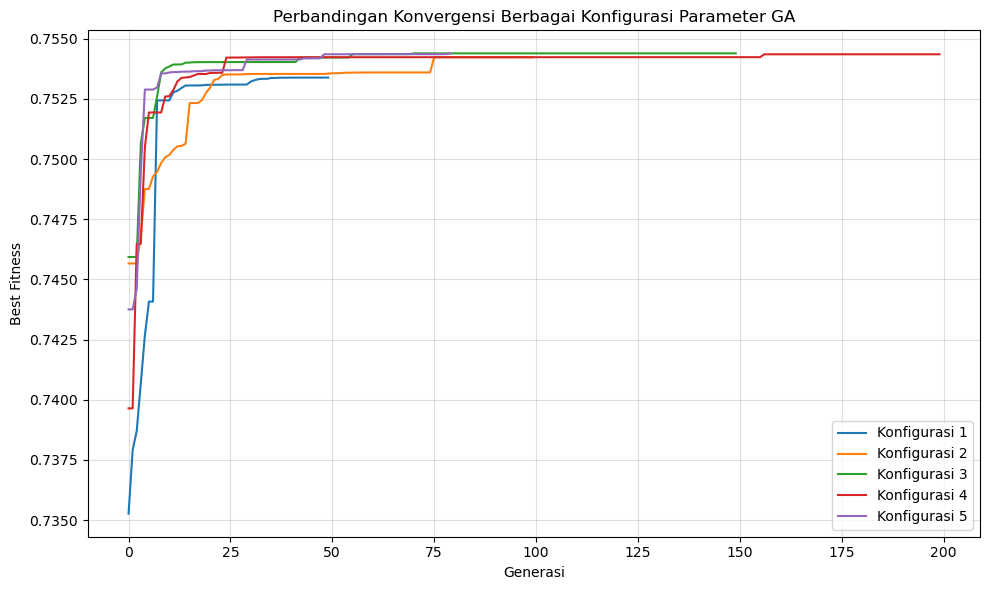

In [4]:
# Grafik 4.2 — Perbandingan konvergensi semua konfigurasi
plt.figure(figsize=(10, 6))
for hist in history_all:
    plt.plot(hist["History"], label=f"Konfigurasi {hist['Konfigurasi']}")
plt.title("Perbandingan Konvergensi Berbagai Konfigurasi Parameter GA")
plt.xlabel("Generasi")
plt.ylabel("Best Fitness")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("grafik_perbandingan_konfigurasi.png", dpi=150)
plt.show()

Konfigurasi terbaik (efisien): K5.0


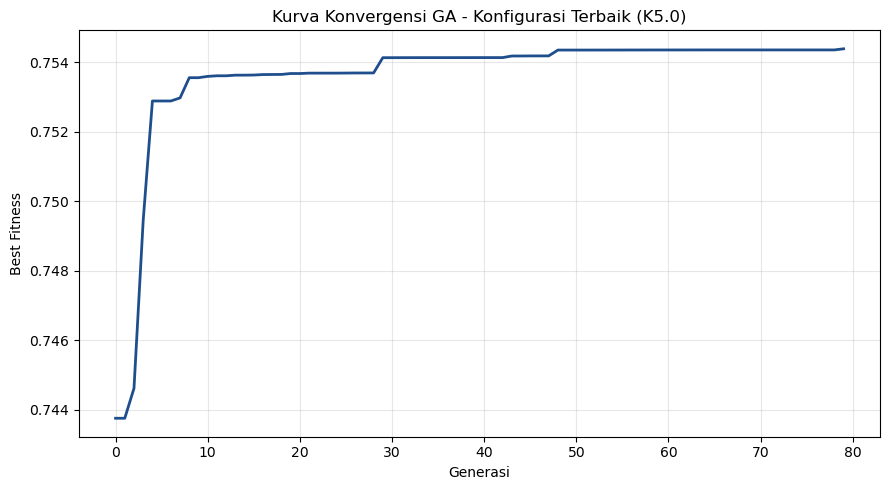

In [5]:
# Semua konfigurasi mencapai fitness yang nyaris setara (selisih < 0.0004),
# sehingga parameter hampir tidak memengaruhi KUALITAS akhir, hanya efisiensi.
# Konfigurasi dengan beban komputasi berlebihan (pop x gen besar) tidak memberi
# peningkatan fitness yang berarti. Maka konfigurasi terbaik dipilih dari yang
# EFISIEN: fitness tertinggi di antara konfigurasi dengan beban komputasi wajar.
beban = df_hasil["Populasi"] * df_hasil["Generasi"]
efisien = df_hasil[beban <= 8000]
best_config = efisien.sort_values("Best Fitness", ascending=False).iloc[0]
print(f"Konfigurasi terbaik (efisien): K{best_config['Konfigurasi']}")

# Grafik 4.1 — Kurva konvergensi konfigurasi terbaik
hist_best = next(h["History"] for h in history_all
                 if h["Konfigurasi"] == best_config["Konfigurasi"])
plt.figure(figsize=(9, 5))
plt.plot(hist_best, color="#1f4e8c", linewidth=2)
plt.title(f"Kurva Konvergensi GA - Konfigurasi Terbaik (K{best_config['Konfigurasi']})")
plt.xlabel("Generasi")
plt.ylabel("Best Fitness")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("grafik_konvergensi_terbaik.png", dpi=150)
plt.show()

In [6]:
# Menyimpan hasil eksperimen ke Excel (2 sheet: ringkasan + konvergensi per generasi)
import numpy as np
konv_len = max(len(h["History"]) for h in history_all)
df_konv = pd.DataFrame({"Generasi": range(1, konv_len + 1)})
for h in history_all:
    col = list(h["History"]) + [np.nan] * (konv_len - len(h["History"]))
    df_konv[f"Konfigurasi {h['Konfigurasi']}"] = col

with pd.ExcelWriter("hasil_eksperimen.xlsx", engine="openpyxl") as xl:
    df_hasil.to_excel(xl, sheet_name="Hasil Eksperimen", index=False)
    df_konv.to_excel(xl, sheet_name="Konvergensi per Generasi", index=False)
print("File Excel hasil eksperimen disimpan sebagai: hasil_eksperimen.xlsx")

File Excel hasil eksperimen disimpan sebagai: hasil_eksperimen.xlsx


In [7]:
# Menulis ringkasan konfigurasi terbaik untuk Orang 1 (laporan)
summary = f"""
===========================================================
RINGKASAN HASIL EKSPERIMEN (OPTIMASI BOBOT - SPEARMAN)
===========================================================

Berdasarkan pengujian terhadap {len(configs)} konfigurasi parameter yang berbeda,
didapatkan bahwa Konfigurasi {best_config['Konfigurasi']} memberikan hasil terbaik.

Detail Parameter Terbaik:
- Populasi        : {best_config['Populasi']}
- Generasi        : {best_config['Generasi']}
- Crossover Rate  : {best_config['Crossover Rate']}
- Mutation Rate   : {best_config['Mutation Rate']}

Hasil yang Dicapai:
- Best Fitness        : {best_config['Best Fitness']}
- Korelasi Spearman   : {best_config['Best Spearman']}
- Rata-rata Fitness   : {best_config['Rata-rata Fitness']}
- Generasi Terbaik    : Ditemukan pada generasi ke-{best_config['Generasi Terbaik']}
- Waktu Komputasi     : {best_config['Waktu Komputasi (s)']} detik

Bobot Optimal (jumlah = 1):
- w_distance : {best_config['w_distance']}
- w_traffic  : {best_config['w_traffic']}
- w_weather  : {best_config['w_weather']}
- w_vehicle  : {best_config['w_vehicle']}
- w_agent    : {best_config['w_agent']}

Pembanding baseline equal-weight: Spearman = 0.4295 (fitness = 0.7148)

Catatan: Seluruh konfigurasi konvergen ke fitness yang nyaris setara
(selisih < 0.0004 / Spearman ~0.509), sehingga parameter tidak banyak
memengaruhi KUALITAS akhir, melainkan kecepatan konvergensi dan efisiensi.

Kesimpulan:
Karena semua konfigurasi setara secara kualitas dan seluruhnya mengungguli
baseline equal-weight, Konfigurasi {best_config['Konfigurasi']} (populasi {best_config['Populasi']}, generasi {best_config['Generasi']},
Crossover Rate {best_config['Crossover Rate']}, Mutation Rate {best_config['Mutation Rate']}) dipilih sebagai konfigurasi
final karena memberikan fitness tertinggi pada beban komputasi yang efisien.
===========================================================
"""
print(summary)
with open("ringkasan_eksperimen.txt", "w", encoding="utf-8") as f:
    f.write(summary)
print("Ringkasan disimpan ke 'ringkasan_eksperimen.txt'.")


RINGKASAN HASIL EKSPERIMEN (OPTIMASI BOBOT - SPEARMAN)

Berdasarkan pengujian terhadap 5 konfigurasi parameter yang berbeda,
didapatkan bahwa Konfigurasi 5.0 memberikan hasil terbaik.

Detail Parameter Terbaik:
- Populasi        : 80.0
- Generasi        : 80.0
- Crossover Rate  : 0.75
- Mutation Rate   : 0.25

Hasil yang Dicapai:
- Best Fitness        : 0.754389
- Korelasi Spearman   : 0.508778
- Rata-rata Fitness   : 0.753601
- Generasi Terbaik    : Ditemukan pada generasi ke-80.0
- Waktu Komputasi     : 36.03 detik

Bobot Optimal (jumlah = 1):
- w_distance : 0.1194
- w_traffic  : 0.1351
- w_weather  : 0.0556
- w_vehicle  : 0.0012
- w_agent    : 0.6886

Pembanding baseline equal-weight: Spearman = 0.4295 (fitness = 0.7148)

Catatan: Seluruh konfigurasi konvergen ke fitness yang nyaris setara
(selisih < 0.0004 / Spearman ~0.509), sehingga parameter tidak banyak
memengaruhi KUALITAS akhir, melainkan kecepatan konvergensi dan efisiensi.

Kesimpulan:
Karena semua konfigurasi setara secar